# Free-final-time parking verification

This notebook answers two distinct questions.  **(1)** Does the model permit arbitrarily long, completed laps?  **(2)** Does the clarity objective actually prefer the resulting parking limit?  The first is proved constructively below; the second is tested with a reproducible horizon sweep.

The result applies only when there is continuous power input, unbounded battery storage, no positive minimum speed, and $P_{in}>k_h$. A fixed battery or a positive minimum speed removes the noncompactness.

In [1]:
using JuMP, Ipopt, LinearAlgebra, Statistics, DataFrames, Plots

# Toy model parameters (SI units)
const L = 100.0
const P_in = 750.0
const k_h = 10.0
const k_m = 83.0
const u_max = 2.5                 # can be finite; it does not prevent parking
const α = 0.10
const σ = 10.0
const N = 40
const ds = L / N
@assert P_in > k_h "Parking cannot create net energy unless P_in > k_h."
default(lw=2, legend=:bottomright, size=(750, 400))

## 1. Constructive proof of unbounded feasible lap time

Choose one segment to take $R$ seconds, and traverse every other segment at the finite maximum speed. This completes the lap for every finite $R$. Its energy slack is

$$[P_{in}-k_h]R + C - k_m\Delta s^3/R^2,$$

where $C$ is independent of $R$. Since $P_{in}>k_h$, the slack tends to $+\infty$. Hence feasible completed laps exist with $T_{lap}\to\infty$ and the chosen segment's speed $\Delta s/R\to0$.

In [2]:
function certificate(R; N=N)
    Δs = L / N
    dt_fast = Δs / u_max
    dt = vcat(R, fill(dt_fast, N - 1))
    T = sum(dt)
    E_used = sum(k_h .* dt .+ k_m .* Δs^3 ./ dt.^2)
    E_in = P_in * T
    return (; R, T, parked_speed=Δs/R, E_used, E_in, slack=E_in-E_used)
end

R_values = 10.0 .^ range(0, 6; length=100)
certificates = certificate.(R_values)
proof_table = DataFrame(
    dwell_s = [x.R for x in certificates],
    lap_s = [x.T for x in certificates],
    parked_speed_mps = [x.parked_speed for x in certificates],
    energy_slack_J = [x.slack for x in certificates],
)
first(proof_table, 8)

Row,dwell_s,lap_s,parked_speed_mps,energy_slack_J
,Float64,Float64,Float64,Float64
1,1.0,40.0,2.5,-22275.0
2,1.14976,40.1498,2.17437,-21848.3
3,1.32194,40.3219,1.89116,-21482.0
4,1.51991,40.5199,1.64483,-21154.8
5,1.74753,40.7475,1.43059,-20849.6
6,2.00923,41.0092,1.24426,-20552.5
7,2.31013,41.3101,1.08219,-20251.6
8,2.65609,41.6561,0.941234,-19936.4


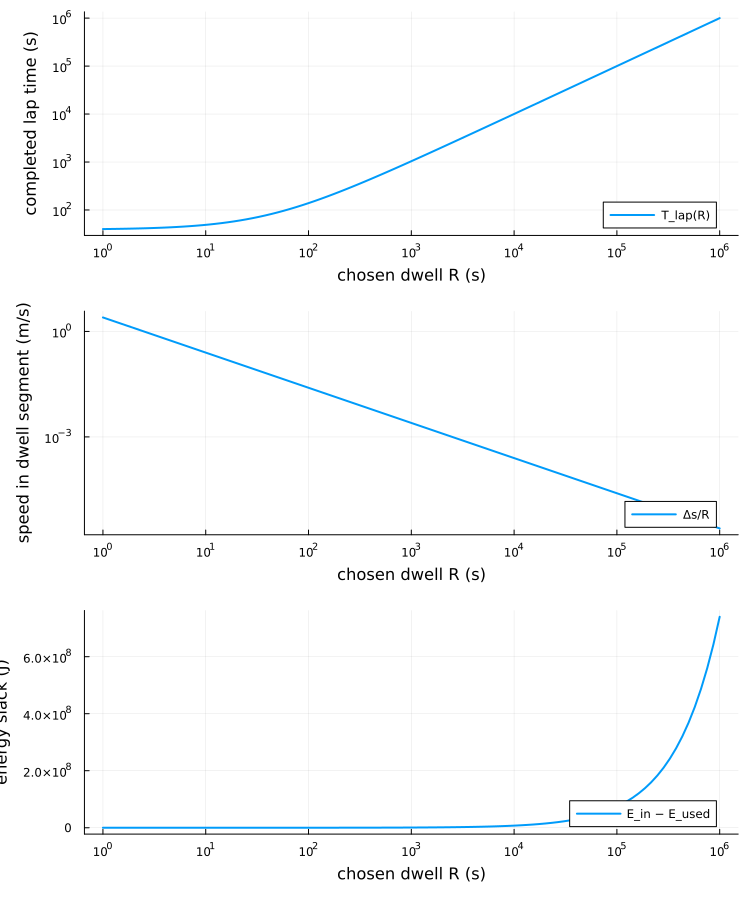

In [3]:
p1 = plot(proof_table.dwell_s, proof_table.lap_s, xscale=:log10, yscale=:log10,
    xlabel="chosen dwell R (s)", ylabel="completed lap time (s)", label="T_lap(R)")
p2 = plot(proof_table.dwell_s, proof_table.parked_speed_mps, xscale=:log10, yscale=:log10,
    xlabel="chosen dwell R (s)", ylabel="speed in dwell segment (m/s)", label="Δs/R")
p3 = plot(proof_table.dwell_s, proof_table.energy_slack_J, xscale=:log10,
    xlabel="chosen dwell R (s)", ylabel="energy slack (J)", label="E_in − E_used")
plot(p1, p2, p3, layout=(3,1), size=(750,900))

The preceding cells are the proof. They do **not** prove that an optimizer chooses this limit: that requires comparing its limiting clarity with finite-horizon patrols. The remaining cells perform that comparison.

In [4]:
circular_distance(a, b) = min(abs(a-b), L-abs(a-b))
s_grid = (0:N-1) .* ds
Smat = [exp(-circular_distance(s_grid[j], s_grid[k])^2 / (2σ^2)) for j in 1:N, k in 1:N]

# Both integrate to L, so the comparison changes only the spatial distribution of importance.
w_uniform = ones(N)
w_peaked_raw = 1 .+ 8 .* exp.(-((s_grid .- 0.30L) ./ (0.07L)).^2)
w_peaked = w_peaked_raw .* (sum(w_uniform) / sum(w_peaked_raw))
@assert isapprox(sum(w_uniform)*ds, sum(w_peaked)*ds)

# Steady clarity if the vehicle stays at segment k indefinitely.
qeq(S) = sqrt(S) / (sqrt(S) + sqrt(α))
function parked_limit(weights)
    values = [sum(weights .* qeq.(Smat[:, k])) * ds for k in 1:N]
    k = argmax(values)
    return (; J=values[k], segment=k, q=qeq.(Smat[:, k]), all_values=values)
end
limits = Dict("uniform" => parked_limit(w_uniform), "peaked" => parked_limit(w_peaked))
DataFrame(case=collect(keys(limits)), parked_limit_J=[limits[x].J for x in keys(limits)],
          best_parked_segment=[limits[x].segment for x in keys(limits)])

Row,case,parked_limit_J,best_parked_segment
,String,Float64,Int64
1,peaked,56.7123,13
2,uniform,38.754,3


In [5]:
function solve_capped_problem(weights, T_max; print_level=0)
    model = Model(Ipopt.Optimizer)
    set_attribute(model, "print_level", print_level)
    set_attribute(model, "max_iter", 3000)
    # No positive speed floor: dt may be large. A finite u_max is retained.
    @variable(model, ds/u_max <= dt[1:N] <= T_max, start=min(L/(1.25N), T_max/N))
    @variable(model, 0 <= q[1:N, 1:N+1] <= 1, start=0.5)
    @variable(model, 0 <= T <= T_max, start=min(L/1.25, T_max))
    @variable(model, 0 <= J <= sum(weights)*ds, start=0.5sum(weights)*ds)
    @constraint(model, T == sum(dt))
    @NLconstraint(model, J*T == sum(weights[j] * 0.5*(q[j,k]+q[j,k+1]) * dt[k] * ds for j in 1:N, k in 1:N))
    @NLconstraint(model, sum(k_h*dt[k] + k_m*ds^3/dt[k]^2 for k in 1:N) <= P_in*T)
    for j in 1:N, k in 1:N
        knext = k == N ? 1 : k+1
        @NLconstraint(model, q[j,k+1] == q[j,k] + 0.5dt[k] *
            ((Smat[j,k]*(1-q[j,k])^2 - α*q[j,k]^2) +
             (Smat[j,knext]*(1-q[j,k+1])^2 - α*q[j,k+1]^2)))
    end
    @constraint(model, [j=1:N], q[j,1] == q[j,N+1])
    @objective(model, Max, J)
    optimize!(model)
    ok = termination_status(model) in (MOI.LOCALLY_SOLVED, MOI.OPTIMAL)
    ok || error("Ipopt did not solve at T_max=$T_max: $(termination_status(model))")
    d = value.(dt)
    return (; J=objective_value(model), T=value(T), dt=d, u=ds./d, status=termination_status(model))
end

solve_capped_problem (generic function with 1 method)

In [6]:
# Increase this range if the last rows still bind T_max.
horizons = [80.0, 120.0, 180.0, 270.0, 405.0, 610.0, 915.0]
runs = DataFrame(case=String[], T_max_s=Float64[], T_lap_s=Float64[], J=Float64[],
                min_speed_mps=Float64[], T_fraction=Float64[], parked_limit_J=Float64[])
profiles = Dict{Tuple{String,Float64}, Vector{Float64}}()
for (name, weights) in [("uniform", w_uniform), ("peaked", w_peaked)]
    for H in horizons
        sol = solve_capped_problem(weights, H)
        push!(runs, (name, H, sol.T, sol.J, minimum(sol.u), sol.T/H, limits[name].J))
        profiles[(name,H)] = sol.u
    end
end
runs


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Row,case,T_max_s,T_lap_s,J,min_speed_mps,T_fraction,parked_limit_J
,String,Float64,Float64,Float64,Float64,Float64,Float64
1,uniform,80.0,48.2261,49.6061,2.07357,0.602826,38.754
2,uniform,120.0,48.2261,49.6061,2.07357,0.401884,38.754
3,uniform,180.0,48.2261,49.6061,2.07357,0.267923,38.754
4,uniform,270.0,48.2261,49.6061,2.07357,0.178615,38.754
5,uniform,405.0,48.2261,49.6061,2.07357,0.119077,38.754
6,uniform,610.0,48.2261,49.6061,2.07357,0.0790592,38.754
7,uniform,915.0,48.2261,49.6061,2.07357,0.0527061,38.754
8,peaked,80.0,80.0,54.7424,0.0881924,1.0,56.7123
9,peaked,120.0,120.0,55.6893,0.0402203,1.0,56.7123


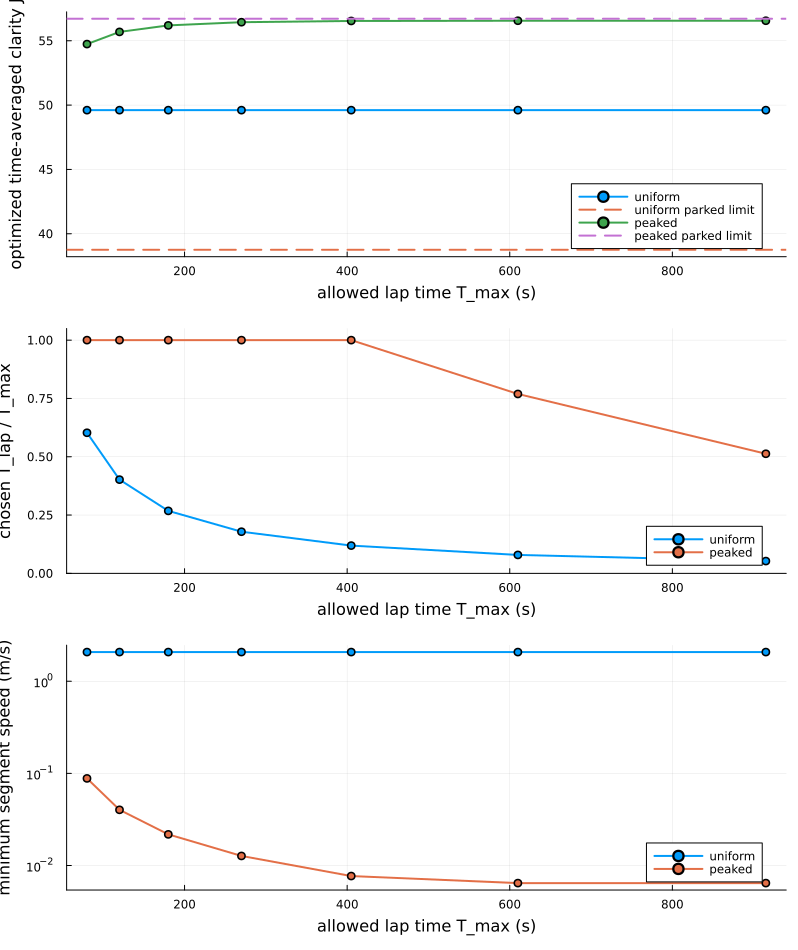

In [7]:
pJ = plot(xlabel="allowed lap time T_max (s)", ylabel="optimized time-averaged clarity J")
pT = plot(xlabel="allowed lap time T_max (s)", ylabel="chosen T_lap / T_max", ylims=(0,1.05))
pu = plot(xlabel="allowed lap time T_max (s)", ylabel="minimum segment speed (m/s)", yscale=:log10)
for name in unique(runs.case)
    r = filter(:case => ==(name), runs)
    plot!(pJ, r.T_max_s, r.J, marker=:circle, label=name)
    hline!(pJ, [r.parked_limit_J[1]], ls=:dash, label="$name parked limit")
    plot!(pT, r.T_max_s, r.T_fraction, marker=:circle, label=name)
    plot!(pu, r.T_max_s, r.min_speed_mps, marker=:circle, label=name)
end
plot(pJ, pT, pu, layout=(3,1), size=(800,950))

## Reading the result for the PI

- The certificate proves that every finite member of the constructed family completes the lap, while its lap time diverges and its selected speed approaches zero.
- If the horizon sweep keeps selecting $T_{lap}/T_{max}\approx1$, minimum speed decreases as $T_{max}$ grows, and $J$ approaches the dashed parked-limit line from below, that is numerical evidence that the free-final-time optimum is a parking-limit maximizing sequence rather than a finite patrol.
- If these curves stabilize away from the horizon bound and above the parked limit, the objective instead prefers a finite patrol.
- Comparing the solid uniform and peaked curves isolates weighting: both weights have the same spatial integral. If uniform still drives the horizon bound, uneven weighting is not the root cause.

A physically well-posed alternative must add at least one missing resource: a fixed/deadline lap time, a positive minimum speed, finite battery capacity with state-of-charge dynamics, or a time/energy cost that cannot be offset by indefinite harvesting.